### Neural Network Classification with Pytorch

In [1]:
# Making classification data and getting it ready 
import sklearn
from sklearn.datasets import make_circles

# Make a 1000 samples 
n_samples = 1000

# Create the circles 
X,y = make_circles(n_samples, noise=0.03, random_state=42)
len(X), len(y)
                    



(1000, 1000)

In [2]:
print(f"First 5 samples of X:\n {X[:5]}")
print(f"First 5 samples of y:\n {y[:5]}")

First 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y:
 [1 1 1 1 0]


In [3]:
# Making dataframes of circle data 
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0],
                        "X2": X[:, 1],
                        "label": y})
circles

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


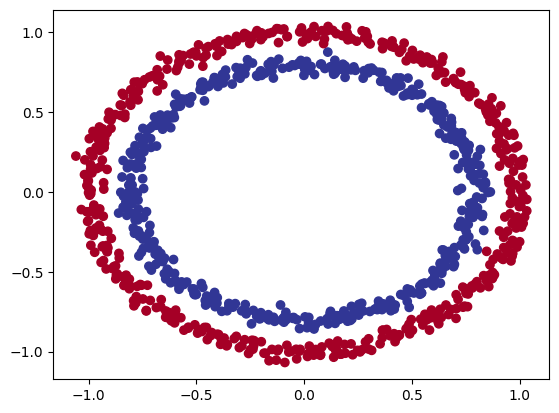

In [4]:
# Visualize, visualize, visualize
import matplotlib.pyplot as plt 
plt.scatter(x= X[:,0],
            y = X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu);

##### Note
* The data we are workin on is called toy dataset, its small enough to run experiments but sizeable enough to run fundamentals 


## Checking input and output shapes

In [5]:
X.shape, y.shape # (1000, 2) means that there are 1000 samples and x has two attributes

((1000, 2), (1000,))

In [6]:
# View sample values for x and y 
X_sample = X[0]
y_sample = y[0]
print(f"values for one sample of X:{X_sample} and one sample of y {y_sample}")
print(f"shape for  X: {X_sample.shape}, y: {y_sample.shape}")

values for one sample of X:[0.75424625 0.23148074] and one sample of y 1
shape for  X: (2,), y: ()


In [7]:
import torch 
import numpy as np 
# turning data into tensors, creating train and tests spilts 
# first we'll make sure whethere whats the data type and what data structure it is in 

type(X)


# After this we will go for coversion 
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:5], y[:5]    

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [8]:
# Splitting data into training and testing data sets 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20 percent test rest training
                                                    random_state= 42)
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test)) 


800
200
800
200


### Building a model 
1. set up our agonistic code, so our code will run on accelerator (google colab)
2. Construct a model using `nn.module`
3. Defining loss function and optimizer 
4. Creating training and testing loops 


#### Model code architecture 
1. Subclasses `nn.module` (almost all models in pytorch use subclass `nn.module`)
2. Create `nn.linear()` layers capable of handling the shapes of our data 
3. defines a `forward()` pass or the forward computation of the model 
4. Instatiate an instance of our model class and send it to target device

In [9]:
from torch import nn
# Construct a model that subclasses nn.module 
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # Create 2 nn.linear layers to handle the shape of data 
        self.layer_1 = nn.Linear(in_features=2, out_features=5) 
        
        # out features of the previus layer have to meet the in features of the next layer, out features are mostly multiples of 8, it takes in 2 features and upscales to 5 features
        
        # the upscaled layers are the hidden layers. the rule of the thumb is that the higher the number of hidden layer, the more the opportunities for the model to learn 

        self.layer_2 = nn.Linear(in_features=5,out_features=1 )
        # takes in 5 features and outputs 1 layer, same shape as y 

        # Define a forward() method that outlines the forward pass 
    def forward(self,x):
        return self.layer_2(self.layer_1(x)) # this works like fiest x is passed through layer 1 and then layer 2    
        
# Instantiate an instance of our model class to send it to target device 

model_0 = CircleModelV0()
model_0



CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [10]:
# Replicating our model using nn.sequential 
#model_0 = nn.Sequential(
   # nn.Linear(in_features=2, out_features=5),
   # nn.Linear(in_features=5, out_features= 1)
#)
# this is an easier way of building neural networks, we went for the subclassing because it can extend to handle lot more complex neural networks 

In [11]:
# Making predictions with model 
model_0.state_dict()



OrderedDict([('layer_1.weight',
              tensor([[-0.1247, -0.2853],
                      [-0.1636,  0.5294],
                      [ 0.4538,  0.2608],
                      [-0.3158,  0.5997],
                      [-0.3159, -0.4658]])),
             ('layer_1.bias',
              tensor([ 0.6524,  0.1196, -0.1573,  0.2854,  0.5358])),
             ('layer_2.weight',
              tensor([[-0.4333, -0.3078,  0.2553,  0.4102,  0.2648]])),
             ('layer_2.bias', tensor([-0.3070]))])

In [12]:
untrained_preds = model_0(X_test)
with torch.inference_mode():
    print(f"length of predictions: {len(untrained_preds)}, shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"first 10 predictions: {torch.round(untrained_preds[:10])}")
print(f"first ten labels: {y_test[:10]}")

length of predictions: 200, shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])
first 10 predictions: tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-1.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.]], grad_fn=<RoundBackward0>)
first ten labels: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


#### Setting up a loss function
* which loss function should you use, this is very problem specific choice
for regression type data where you are predicting a number, go for MAE or MSE 
mean absolute error and mean squred error. 
If we go for categorical predictions we go for binary cross entorpy and  categorical cross entropy 

#### Binary Cross Entropy 
* A loss function for binary classification (0 or 1) that measures the performance of a model by comparing predicted probabilities to true labels.

#### Cross Entropy Classification 
* Measures the dissimilarity between a model's predicted probability distribution and the true distribution of labels (0 or 1) in classification tasks.

* For optimizers, mainly SGD and Adams are used but pytorch as various buit in optimizers as well
* For definition of logit and its meaning, checkout pytorch's official documentation 

#### Sigmoid Activation: 
* This function maps any real-valued number into a value between 0 and 1, interpreting the output as the probability of a data sample belonging to the positive class (class 1).


#### Binary Cross-Entropy Loss (BCE): 
* This function measures the difference between the predicted probability and the true label (0 or 1). It heavily penalizes confident but wrong predictions.


In [13]:
# Setting up a loss function 
# loss_fn = nn.BCEloss(), the inputs have to go through sigmoid activation prior to be input to this 
loss_fn = nn.BCEWithLogitsLoss() # it has built in sigmoid activation function 

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [14]:
# Calculating accuracy - it is a necessity to calculate this in classfication models 
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item() #torch.eq() is checking how many y_true are equal to y_pred 
    acc = (correct/len(y_pred))*100 
    return acc

#### Training loop 
1. Forward pass
2. Calculate the loss 
3. Optimizer zero grad
4. Loss backward (backpropogation)
5. Optimizer Step (gradient descent)

#### Going from raw logits -> Prediction probabilities -> Prediction labels 
* We convert these **LOGITS** into prediction probabilities by passing them through an activation function (in this case, the sigmoid for binary cross entropy)

* Further these prediction probabilites are converted to prediction labels by taking **argmax()** 

In [15]:
# Viewing first 5 outputs of the forward pass 
y_logits = model_0(X_test[:5])
y_logits 

# now we are gonna convert them into prediction probabilites, whenver we pass data through a linear layer, a mathematical function is performed y=xA^T + B.

# Using sigmoid activation function, this tells how likely our model thinks of teh certain class
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], grad_fn=<RoundBackward0>)

#### For our prediction labels we'll have to perform range type rounding off 
* If `y_preds_probs` > `0.5`, *y=1* [class_1]
* If `y_preds_probs` <> `0.5`, *y=0* [class_0]


In [16]:
# Find the predicted labels 
y_preds = torch.round(y_pred_probs)

# In full ( logits -> prediction probabiltites -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test[:5])))

# Checking for eqaulity 
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension 
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.], grad_fn=<SqueezeBackward0>)

* Above all after setting up the optimizer and loss function was an explanation so as to why are we doin this and why does it matter to have that particular kind of optimizer function 

### Builidng a Training and testing loop 


In [17]:
torch.manual_seed(42)
torch.cuda.manual_seed(42) # this is for if you're using colab cus there you have to specify where you're performing computations 

# Setting up Epochs
epochs = 100


#Put data to target device 
#X_train, y_train = X_train.to(device), y_train.to(device)
#X_test, y_test = X_test.to(device), y_train.to(device)
#again, these are specifically for using google colab and not for local machines, you can but its really unnecessary 

# Building the training and evaluation loop 

for epoch in range (epochs):
    # Training
    model_0.train()


    # 1. Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits into pred probs further into pred labels 



    #2. Calculating loss/accuracy 
    loss = loss_fn(y_logits, # nn.BCEwithlogits expects raw logits as input 
                   y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)
    
    # #3. Setting up optimizer grad
    optimizer.zero_grad()

    # 4.  Loss Backward (backpropagation)
    loss.backward()


    #5. Optimizer step (gradient descent)
    optimizer.step()

    # Testing Looooooooop

    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate the test loss/ accuracy 
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true= y_test,
                               y_pred = test_pred)
        
    # Printing what's goin
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc: .2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")




Epoch: 0 | Loss: 0.71433, Acc:  50.00% | Test loss: 0.71467, Test acc: 50.00
Epoch: 10 | Loss: 0.69940, Acc:  50.00% | Test loss: 0.70089, Test acc: 50.00
Epoch: 20 | Loss: 0.69506, Acc:  50.00% | Test loss: 0.69667, Test acc: 50.00
Epoch: 30 | Loss: 0.69378, Acc:  46.38% | Test loss: 0.69530, Test acc: 41.50
Epoch: 40 | Loss: 0.69338, Acc:  47.88% | Test loss: 0.69481, Test acc: 49.00
Epoch: 50 | Loss: 0.69324, Acc:  48.38% | Test loss: 0.69461, Test acc: 49.50
Epoch: 60 | Loss: 0.69317, Acc:  49.38% | Test loss: 0.69452, Test acc: 50.00
Epoch: 70 | Loss: 0.69313, Acc:  49.62% | Test loss: 0.69447, Test acc: 48.50
Epoch: 80 | Loss: 0.69310, Acc:  49.88% | Test loss: 0.69444, Test acc: 49.00
Epoch: 90 | Loss: 0.69308, Acc:  50.25% | Test loss: 0.69443, Test acc: 49.50


#### Making predictions and evaluating model
* From matrix it seems as if the model isnt learning anything 
* So for testing we'll visualize some predictions, to do so, we are gonna import a function called `plot_decision_boundary()` 

In [18]:
import requests
from pathlib import Path

# download helper functions from pytorch if not already downloaded from learn Pytorch repo
if Path("helper_functions.py").is_file():
    print("helper_functions.py exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with  open("helper_functions.py", "wb") as f:
        f.write(request.content)





helper_functions.py exists, skipping download


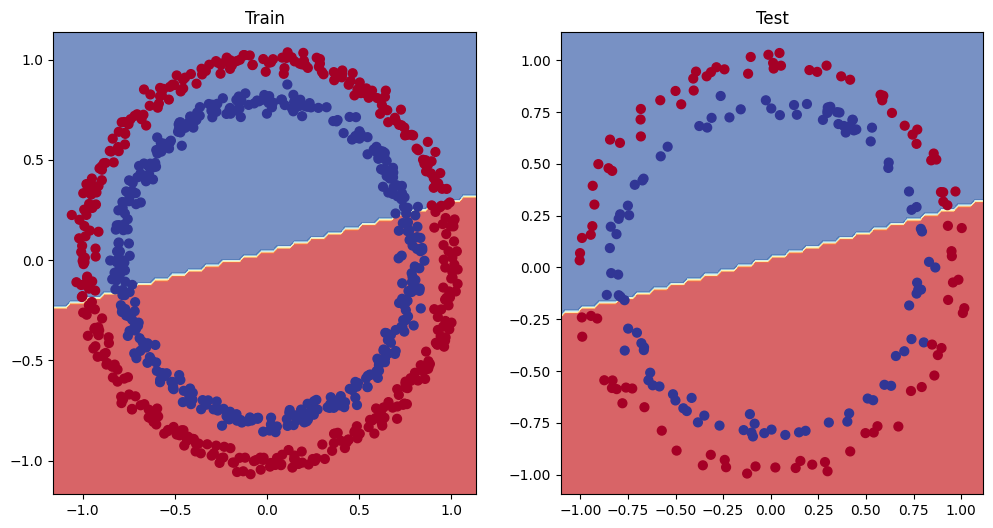

In [19]:
# Plot decision boundary testing
from helper_functions import plot_decision_boundary, plot_predictions 
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)



### Improving from the Model's perpsective 
* Add more layers 
* Add more hidden units 
* Change the loss function
* Change the activation function 
* change the learning rate (this is where two problems emerge, if the lr is too high, the nimbers become extremly large in values causing the model to explode , this is called the `Exploding gradient problem` and if the lr is too small, the slope of numbers become so small that there is no actual change in the machine, its called `Vanishing number problem`)
* the parameters given above are from the model's perspective and therefore are called hyperparameters, we can change them to change the behvaiour of the model
* Improving the model through various methods 
1. Adding more hidden layers
2. Adding extra layer
3. Increasing the number of epochs from 100 to thousand 

`NOTE` - Whenver testing a model, dont change more than one parameter at once to better understand the changes made 

![Ml_pipeline](images/Ml_pipeline.png)

In [20]:
# Creating a subclass changing the hyperparams
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)


    def forward(self,x):
       # z = self.layer_1(x)
       # z = self.layer_2(z)
       # z = self.layer_3(z), we can do this, or we can created nested pathway fro the variable to go from
       return self.layer_3(self.layer_2(self.layer_1(x))) # This kind of code leverages speed ups as computation time is less 

# Creating model isinstance
model_1 = CircleModelV1()
model_1 
# Addin more layers gives the model multiple chances to fix the numbers therefore increases the chances for increasing model's accuracy 


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [21]:
print(model_1)

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)


In [22]:
# Creating a loss function 
loss_fn = nn.BCEWithLogitsLoss()

# Creating an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [23]:
# Writing a training and evaluation loop for model 
torch.manual_seed(42)

# Training the model for longer 
epochs = 1000

for epoch in range(epochs):
    # Training 
    model_1.train()
    # 1. Forward pass 
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> pred probabilities -> predicitons 


    # Calculating the loss function 
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true = y_train,
                       y_pred=y_pred)

    # Optimizer zero grad
    optimizer.zero_grad()

    # loss backward (backpropogation)
    loss.backward()

    # optimizer step (gradient descent)
    optimizer.step()

    # Testing loop 
    model_1.eval()


    with torch.inference_mode():
        # Forward passing
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # Calculating loss
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true = y_test,
                               y_pred = test_pred)
        
    # print out what's happening 
    if epoch %10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc: .2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")



     

Epoch: 0 | Loss: 0.69396, Acc:  50.88% | Test loss: 0.69261, Test acc: 51.00
Epoch: 10 | Loss: 0.69369, Acc:  50.25% | Test loss: 0.69270, Test acc: 50.00
Epoch: 20 | Loss: 0.69351, Acc:  50.12% | Test loss: 0.69283, Test acc: 49.50
Epoch: 30 | Loss: 0.69339, Acc:  50.50% | Test loss: 0.69297, Test acc: 48.00
Epoch: 40 | Loss: 0.69329, Acc:  50.38% | Test loss: 0.69310, Test acc: 49.00
Epoch: 50 | Loss: 0.69322, Acc:  49.88% | Test loss: 0.69324, Test acc: 50.00
Epoch: 60 | Loss: 0.69317, Acc:  49.38% | Test loss: 0.69336, Test acc: 51.50
Epoch: 70 | Loss: 0.69312, Acc:  49.38% | Test loss: 0.69348, Test acc: 50.50
Epoch: 80 | Loss: 0.69309, Acc:  50.12% | Test loss: 0.69359, Test acc: 50.00
Epoch: 90 | Loss: 0.69307, Acc:  50.50% | Test loss: 0.69370, Test acc: 48.50
Epoch: 100 | Loss: 0.69305, Acc:  50.38% | Test loss: 0.69379, Test acc: 48.00
Epoch: 110 | Loss: 0.69303, Acc:  50.88% | Test loss: 0.69388, Test acc: 46.50
Epoch: 120 | Loss: 0.69302, Acc:  50.75% | Test loss: 0.69396, 

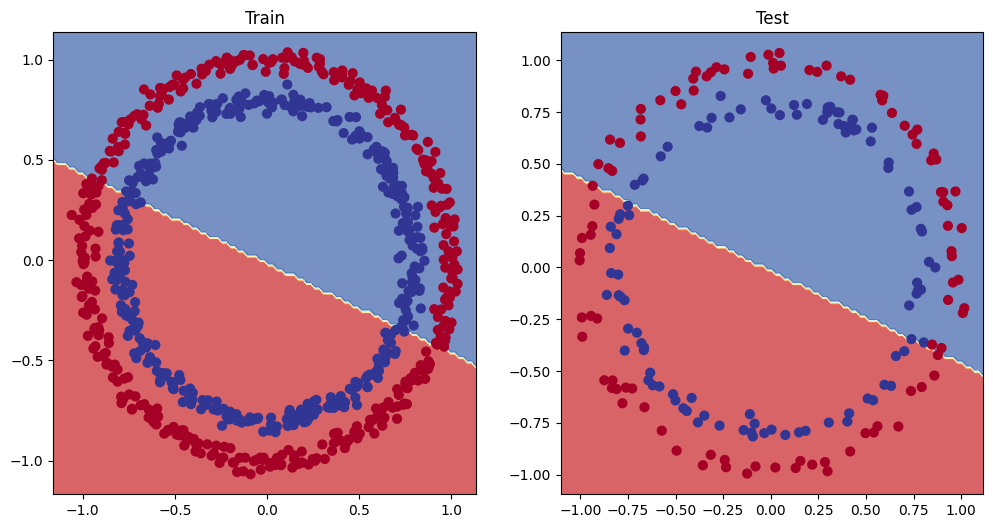

In [24]:
# Plotting the decision boundary 
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)

#### The missing piece of the model: non linear layers 

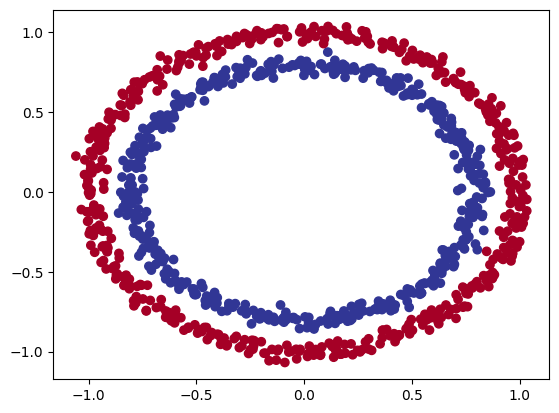

In [25]:
# Creating non linear data 
# make and plot data 
import matplotlib.pyplot as plt 

from sklearn.datasets import make_circles 

n_samples = 1000
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)
plt.scatter(x= X[:,0],
            y = X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu); 

In [26]:
# Converting data to tensors and then splitting 
import torch 
from sklearn.model_selection import train_test_split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

#Split into train and test data 
X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 test_size=0.2,
                                                 random_state=42)
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

* In theory a relu is a non linear activation function which turns negative inputs to zero and leaves the posiitve as they are 

In [27]:
# building a model with non linear activation functions 
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10,out_features=1)
        self.relu = nn.ReLU()
    
    def forward(self,x):
        # Where should one put non-linear activation layers, that is, between the linear layers 
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
model_3 = CircleModelV2()
model_3

    
    

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [28]:
# Creating a loss function 
loss_fn = nn.BCEWithLogitsLoss()

# Creating an optimizer
optimizer = torch.optim.SGD(params=model_3.parameters(),
                            lr=0.1)

In [31]:
# Writing a training and evaluation loop for model 
import torch
torch.manual_seed(42)

# Training the model for longer 
epochs = 2000

for epoch in range(epochs):
    # Training 
    model_3.train()
    # 1. Forward pass 
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> pred probabilities -> predicitons 


    # Calculating the loss function 
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true = y_train,
                       y_pred=y_pred)

    # Optimizer zero grad
    optimizer.zero_grad()

    # loss backward (backpropogation)
    loss.backward()

    # optimizer step (gradient descent)
    optimizer.step()

    # Testing loop 
    model_3.eval()


    with torch.inference_mode():
        # Forward passing
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # Calculating loss
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true = y_test,
                               y_pred = test_pred)
        
    # print out what's happening 
    if epoch %10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc: .2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")



     

Epoch: 0 | Loss: 0.56818, Acc:  87.75% | Test loss: 0.57378, Test acc: 86.50
Epoch: 10 | Loss: 0.56076, Acc:  88.50% | Test loss: 0.56745, Test acc: 88.50
Epoch: 20 | Loss: 0.55314, Acc:  89.25% | Test loss: 0.56086, Test acc: 89.50
Epoch: 30 | Loss: 0.54521, Acc:  90.00% | Test loss: 0.55402, Test acc: 89.50
Epoch: 40 | Loss: 0.53698, Acc:  90.75% | Test loss: 0.54690, Test acc: 90.00
Epoch: 50 | Loss: 0.52849, Acc:  91.38% | Test loss: 0.53950, Test acc: 89.50
Epoch: 60 | Loss: 0.51973, Acc:  92.38% | Test loss: 0.53196, Test acc: 89.50
Epoch: 70 | Loss: 0.51060, Acc:  92.75% | Test loss: 0.52411, Test acc: 90.00
Epoch: 80 | Loss: 0.50114, Acc:  93.25% | Test loss: 0.51589, Test acc: 90.00
Epoch: 90 | Loss: 0.49146, Acc:  93.50% | Test loss: 0.50766, Test acc: 89.50
Epoch: 100 | Loss: 0.48153, Acc:  93.50% | Test loss: 0.49935, Test acc: 90.50
Epoch: 110 | Loss: 0.47130, Acc:  94.25% | Test loss: 0.49084, Test acc: 89.50
Epoch: 120 | Loss: 0.46067, Acc:  94.62% | Test loss: 0.48221, 

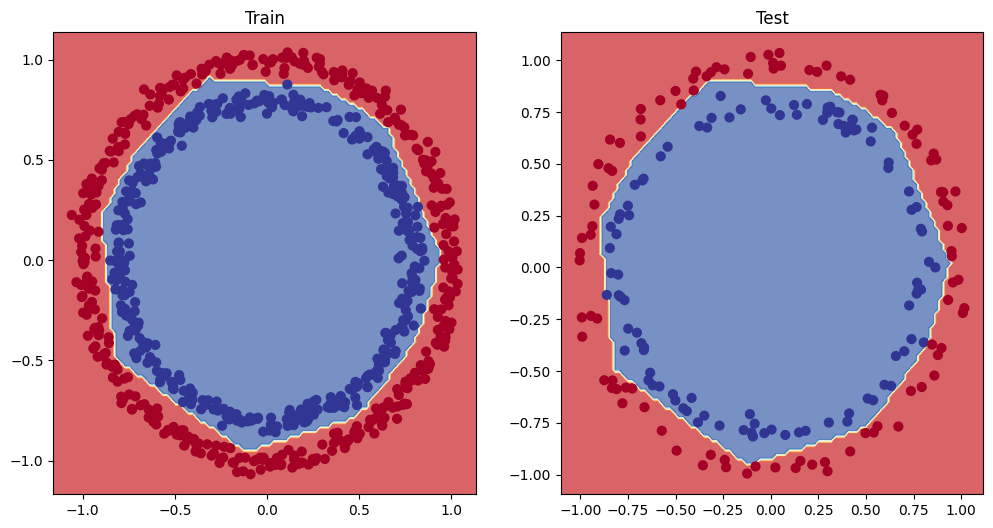

In [32]:
# Plotting the decision boundary 
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,X_test,y_test)